# Análisis Exploratorio de Datos (EDA): Incidentes de Focos de Calor en Europa (MODIS)

## **1. Configuración del entorno y carga de datos**

In [1]:
import os
import glob
import io
import time
from io import StringIO
from pathlib import Path as SystemPath
import nbformat
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import openpyxl
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.path import Path
import seaborn as sns
import contextily as ctx
import geodatasets
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import streamlit as st
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    IsolationForest, 
    RandomForestClassifier, 
    RandomForestRegressor, 
    HistGradientBoostingClassifier
)
from sklearn.linear_model import Ridge
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)
import requests
from io import StringIO
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.cluster import HDBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Unificación y consolidación de datasets (pipeline de ingesta)
ruta_paises = SystemPath("data/paises")
ruta_salida = SystemPath("data/unificado")

ruta_salida.mkdir(parents=True, exist_ok=True)

patron_busqueda = str(ruta_paises / "modis_2024_*.csv")
archivos_csv = glob.glob(patron_busqueda)

if archivos_csv:
    lista_dataframes = []
    
    for ruta_str in archivos_csv:
        archivo = SystemPath(ruta_str)
        pais = archivo.stem.replace("modis_2024_", "").capitalize() 
        
        df_temporal = pd.read_csv(archivo)
        df_temporal['pais'] = pais
        lista_dataframes.append(df_temporal)
    
    df_unificado = pd.concat(lista_dataframes, ignore_index=True)
    
    ruta_archivo_final = ruta_salida / "modis_2024_unificado.csv"
    df_unificado.to_csv(ruta_archivo_final, index=False)

df = pd.read_csv(r'data/unificado/modis_2024_unificado.csv')

c:\Users\felix\Documents\bootcamp\mes 2\PiroVigia_proyecto4_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **2. Limpieza**

In [2]:
# Diagnóstico de calidad de datos
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores No Nulos': df.count(),
    'Valores Nulos': df.isnull().sum(),
    '% de Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print(" 1. INFO DE DATOS Y CALIDAD:")
display(info_df)  # Usamos display para mostrar ambas tablas de forma interactiva

print("\n 2. VISTA PREVIA DEL DATASET (Primeros registros):")
df.head()

 1. INFO DE DATOS Y CALIDAD:


,Tipo de Dato,Valores No Nulos,Valores Nulos,% de Nulos
latitude,float64,308402,0,0.0
longitude,float64,308402,0,0.0
brightness,float64,308402,0,0.0
scan,float64,308402,0,0.0
track,float64,308402,0,0.0
acq_date,str,308402,0,0.0
acq_time,int64,308402,0,0.0
satellite,str,308402,0,0.0
instrument,str,308402,0,0.0
confidence,int64,308402,0,0.0



 2. VISTA PREVIA DEL DATASET (Primeros registros):


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,pais
0,40.8143,19.6998,300.5,1.1,1.1,2024-01-28,853,Terra,MODIS,37,61.03,280.8,7.9,D,0,Albania
1,40.4384,19.7503,319.6,1.0,1.0,2024-01-28,1218,Aqua,MODIS,79,61.03,285.4,20.4,D,2,Albania
2,40.2651,19.8576,302.3,2.1,1.4,2024-01-31,1244,Aqua,MODIS,49,61.03,286.7,19.0,D,0,Albania
3,39.8510,20.2340,301.5,1.0,1.0,2024-02-04,1213,Aqua,MODIS,35,61.03,288.9,5.3,D,0,Albania
4,40.5204,20.3950,304.2,1.0,1.0,2024-02-04,1213,Aqua,MODIS,46,61.03,288.5,6.3,D,0,Albania


In [3]:
# Ingeniería de características: formateo de fechas y horas
# Convertir la columna 'fecha' a tipo datetime
df['acq_date'] = pd.to_datetime(df['acq_date'], format='%Y-%m-%d')

# Formatear 'acq_time' para que sea consistente con 0 a la izquierda
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)

# Creamos columna 'acq_datetime' combinando 'acq_date' y 'acq_time'
df['acq_datetime'] = pd.to_datetime(
    df['acq_date'].dt.strftime('%Y-%m-%d') + ' ' + df['acq_time'].str[:2] + ':' + df['acq_time'].str[2:4], format='%Y-%m-%d %H:%M')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 308402 entries, 0 to 308401
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   latitude      308402 non-null  float64       
 1   longitude     308402 non-null  float64       
 2   brightness    308402 non-null  float64       
 3   scan          308402 non-null  float64       
 4   track         308402 non-null  float64       
 5   acq_date      308402 non-null  datetime64[us]
 6   acq_time      308402 non-null  str           
 7   satellite     308402 non-null  str           
 8   instrument    308402 non-null  str           
 9   confidence    308402 non-null  int64         
 10  version       308402 non-null  float64       
 11  bright_t31    308402 non-null  float64       
 12  frp           308402 non-null  float64       
 13  daynight      308402 non-null  str           
 14  type          308402 non-null  int64         
 15  pais          308402 non-nul

In [4]:
# Validación de atributos geográficos y rangos de confianza
# Latitud debe estar entre -90 y 90, longitud entre -180 y 180
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180)) &
    (df['latitude'].notnull()) &
    (df['longitude'].notnull())
]

df = df[df['confidence'].between(0, 100)]


In [5]:
# Optimización de memoria y estandarización de variables
# Conversión a categóricas: reducción del uso de memoria en variables cualitativas
df['satellite'] = df['satellite'].astype('category')
df['instrument'] = df['instrument'].astype('category')
df['daynight'] = df['daynight'].astype('category')
df['pais'] = df['pais'].astype('category')
df['type'] = df['type'].astype('category') # tipo de foco (forestal, volcán...)

# Homogeneización númerica: redondeo de valores para estandarizar y reducir ruido
df['brightness'] = df['brightness'].round(2) # temperatura de brillo del pixel medida en Kelvin (temperatura observada desde el espacio en la zona más caliente)
df['bright_t31'] = df['bright_t31'].round(2) # temperatura de brillo del pixel medida en infra-rojo (band 31) (temperatura de la superficie terrestre)
# brightness y bright_t31 se usan para contrastar y distinguir un incendio de otros objetos calientes (asfalto, volcanes)
df['frp'] = df['frp'].round(2) # fire radiative power (potencia radiactiva del fuego) medida en MW (megavatios). Es un indicador de la intensidad del incendio.

In [6]:
# Mapeo y decodificación de variable 'type'
diccionario_tipos = {
    0: 'Incendio forestal/vegetación',
    1: 'Volcán',
    2: 'Industria/Foco estático',
    3: 'Otros/Fuera de rango'
}

# Aplicar el mapeo a la columna type
df['type'] = df['type'].map(diccionario_tipos)

# Asegurarnos de que se guarde como tipo categoría para optimizar
df['type'] = df['type'].astype('category')

# Verificar el cambio
print(df['type'].value_counts())

type
Incendio forestal/vegetación    279748
Industria/Foco estático          26770
Volcán                            1760
Otros/Fuera de rango               124
Name: count, dtype: int64


In [7]:
# Crear la carpeta 'data'
os.makedirs('data', exist_ok=True)

# Modificar la ruta de salida para incluir la carpeta
archivo_salida = 'data/modis_2024_unificado_limpio.csv'

# Guardar los datos limpios dentro de la carpeta (Cambiado df_clean por df)
df.to_csv(archivo_salida, index=False)

print(f"Dimensiones finales tras la limpieza: {df.shape}")
print(f"¡Base de datos limpia guardada como '{archivo_salida}'!")

df_clean = pd.read_csv(r'data/modis_2024_unificado_limpio.csv')
df_clean.head()



OSError: [Errno 22] Invalid argument: 'data/modis_2024_unificado_limpio.csv'

## **3. Análisis de calidad de los datos y filtro de ruido**

Distribución original de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64
Cantidad de registros considerados ruido: 76438 (24.79%) )

Distribución de tipos de focos en el ruido:
type
Incendio forestal/vegetación    68983
Industria/Foco estático          7199
Volcán                            230
Otros/Fuera de rango               26
Name: count, dtype: int64


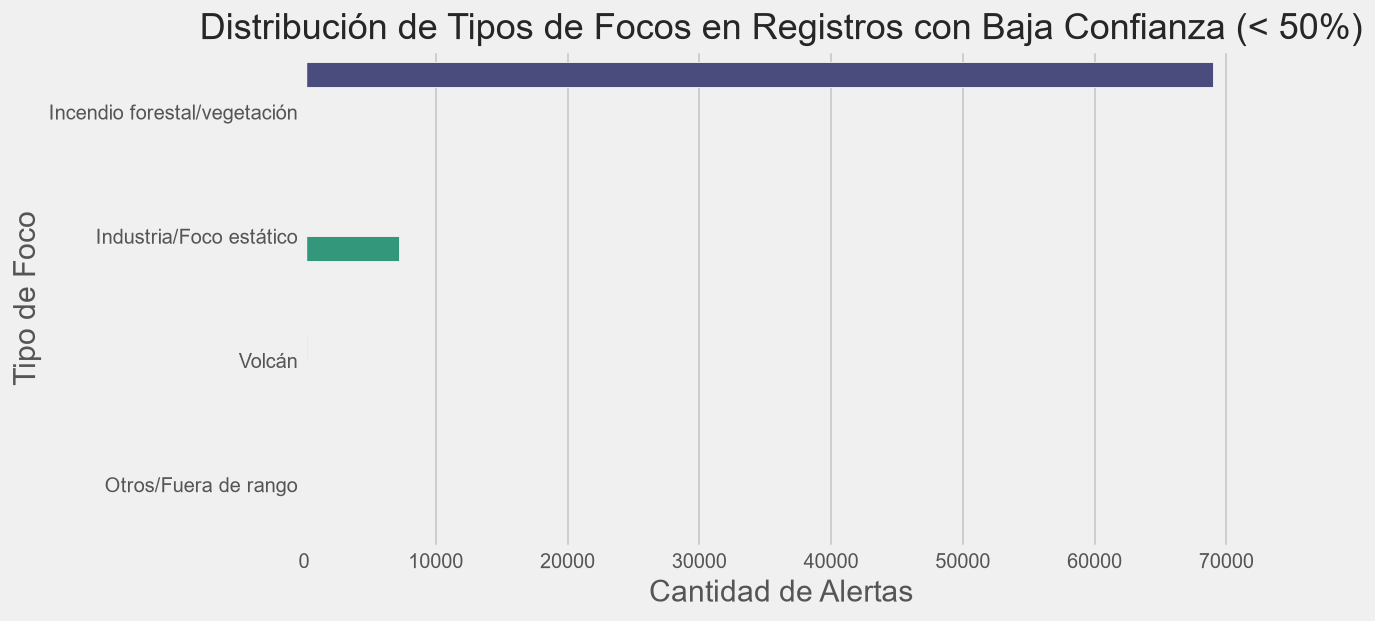


Registros originales: 308402
Registros tras eliminar ruido: 231964
Falsos positivos/Ruido eliminado: 76438 alertas.


In [ ]:
# Evaluación estadística de la métrica de fiabilidad antes de la depuración
# Analizar la distribución de la calidad antes de limpiar
print("Distribución original de confianza:")
print(df_clean['confidence'].describe())

# Creamos un subconjunto de datos sin ruido, eliminando alertas con confianza baja (< 50%)
df_ruido = df[df['confidence'] < 50]
print(f"Cantidad de registros considerados ruido: {df_ruido.shape[0]} ({(df_ruido.shape[0] / len(df_clean) * 100):.2f}%) )")

# Identificación y segmentación de registros de ruido: análisis de tipos de focos
print("\nDistribución de tipos de focos en el ruido:")
print(df_ruido['type'].value_counts())

# Visualización de la distribución del ruido por tipo de foco
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_ruido, 
    y='type', 
    order=df_ruido['type'].value_counts().index,
    hue='type',
    palette='viridis',
    legend=False
)
plt.title('Distribución de Tipos de Focos en Registros con Baja Confianza (< 50%)')
plt.xlabel('Cantidad de Alertas')
plt.ylabel('Tipo de Foco')
plt.tight_layout()
plt.show()

# Aplicar el filtro de ruido: Quedarnos solo con alertas de confianza Media y Alta (>= 50%)
df_sin_ruido = df_clean[df_clean['confidence'] >= 50].copy()

print(f"\nRegistros originales: {len(df_clean)}")
print(f"Registros tras eliminar ruido: {len(df_sin_ruido)}")
print(f"Falsos positivos/Ruido eliminado: {len(df_clean) - len(df_sin_ruido)} alertas.")

Distribución de los niveles de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64


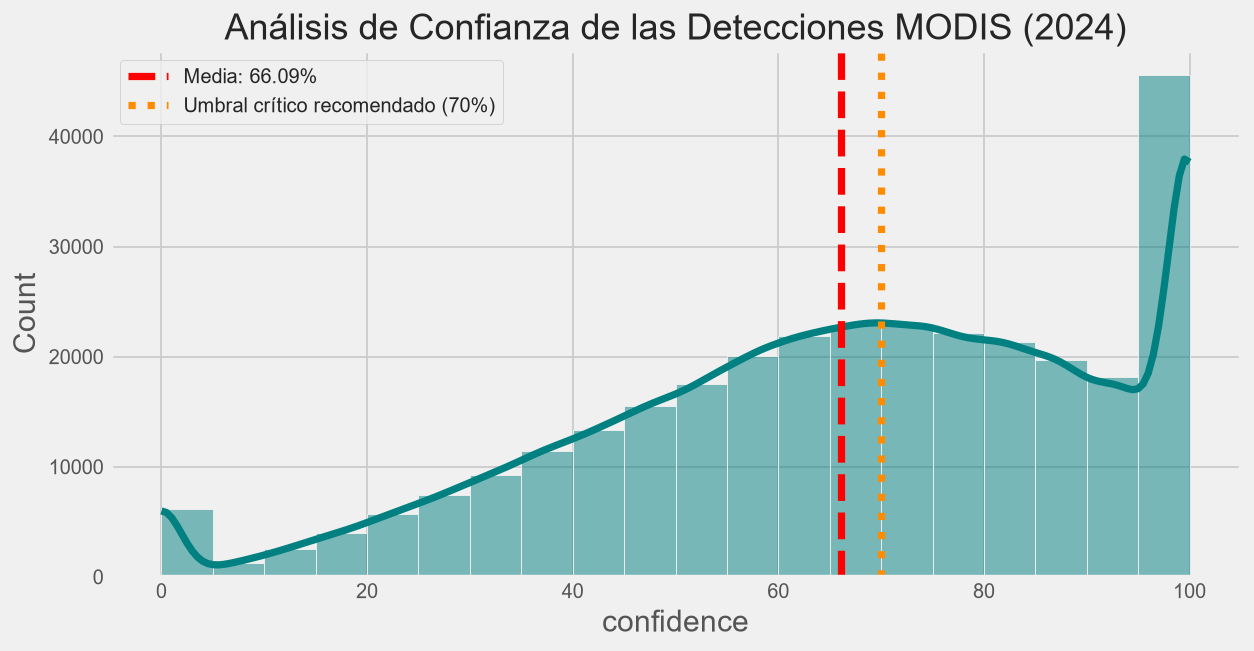

Registros iniciales: 308402 | Registros de alta confianza: 149734


In [ ]:
# Resumen de calidad
print("Distribución de los niveles de confianza:")
print(df['confidence'].describe())

# Visualización de la pureza del dato
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='confidence', kde=True, bins=20, color='teal')
plt.axvline(df['confidence'].mean(), color='red', linestyle='--', label=f"Media: {df['confidence'].mean():.2f}%")
plt.axvline(70, color='darkorange', linestyle=':', label="Umbral crítico recomendado (70%)")
plt.title('Análisis de Confianza de las Detecciones MODIS (2024)')
plt.legend()
plt.show()

# Propuesta de filtrado para análisis de alta certeza
df_high_conf = df[df['confidence'] >= 70]
print(f"Registros iniciales: {len(df)} | Registros de alta confianza: {len(df_high_conf)}")

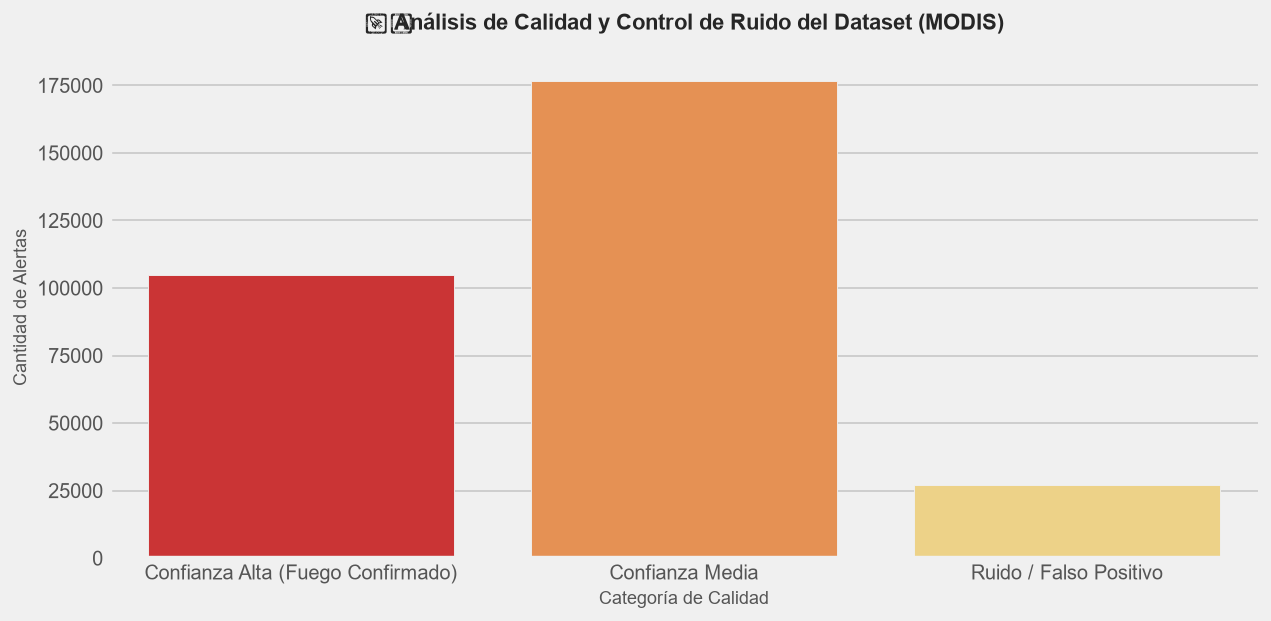

In [ ]:
# Crear categorías de calidad basadas en el estándar MODIS
def clasificar_calidad(conf):
    if conf < 30:
        return 'Ruido / Falso Positivo'
    elif conf < 80:
        return 'Confianza Media'
    else:
        return 'Confianza Alta (Fuego Confirmado)'

# Aplicar la clasificación
df_clean['calidad_alerta'] = df_clean['confidence'].apply(clasificar_calidad)

# Graficar el análisis de calidad para la presentación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean, 
    x='calidad_alerta', 
    palette='YlOrRd_r', 
    order=['Confianza Alta (Fuego Confirmado)', 'Confianza Media', 'Ruido / Falso Positivo']
)

plt.title('🛡️ Análisis de Calidad y Control de Ruido del Dataset (MODIS)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Categoría de Calidad', fontsize=10)
plt.ylabel('Cantidad de Alertas', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## **4. Análisis estadístico descriptivo y diagnóstico de outliers**

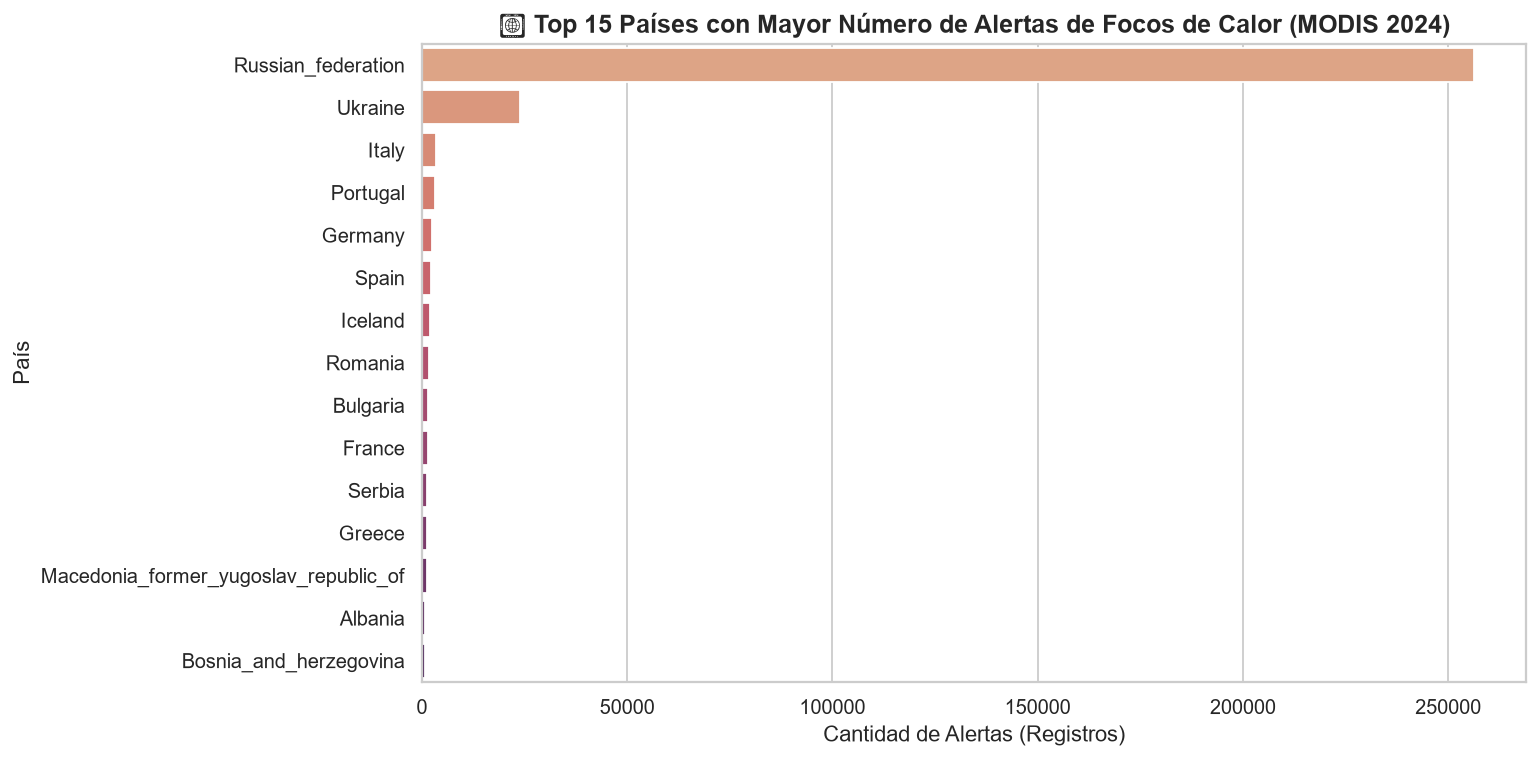

In [ ]:
# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Contar registros por país y seleccionar los 15 principales
top_paises = df_clean['pais'].value_counts().head(15)

# Crear gráfico de barras
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette="flare", legend=False)

plt.title('🔥 Top 15 Países con Mayor Número de Alertas de Focos de Calor (MODIS 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Alertas (Registros)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

## **5. Análisis temporal y evaluación de focos de calor**

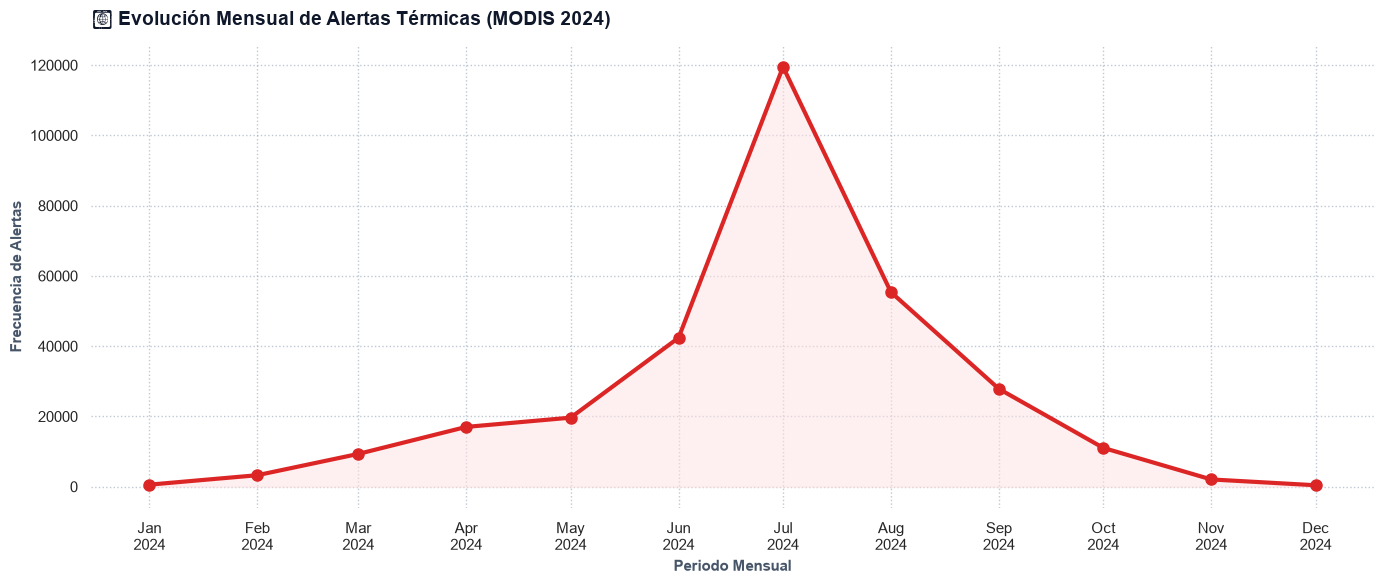

In [ ]:
# Comportamiento temporal de los focos de calor: análisis de evolución mensual
# Tendencia temporal: análisis por mes
# Estética nativa de Jupyter
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def plot_temporal_evolution(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Forzamos la conversión aquí mismo en una variable nueva
    fechas_correctas = pd.to_datetime(dataframe['acq_datetime'], errors='coerce')
    
    # Agrupamos usando 'fechas_correctas', NO 'dataframe'
    focos_por_mes = dataframe.groupby(fechas_correctas.dt.to_period('M')).size()
    focos_por_mes.index = focos_por_mes.index.to_timestamp()
    
    # Gráfico y sombreado
    ax.plot(focos_por_mes.index, focos_por_mes.values, 
            marker='o', markersize=8, color='#dc2626', linewidth=3)
    
    ax.fill_between(focos_por_mes.index, focos_por_mes.values, 
                    color='#fee2e2', alpha=0.5) 
    
    # Formato de fechas en el eje X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    
    # Etiquetas
    ax.set_title('📅 Evolución Mensual de Alertas Térmicas (MODIS 2024)', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a')
    ax.set_xlabel('Periodo Mensual', fontsize=11, fontweight='semibold', color='#475569')
    ax.set_ylabel('Frecuencia de Alertas', fontsize=11, fontweight='semibold', color='#475569')
    
    ax.grid(True, linestyle=':', alpha=0.6, color='#94a3b8')
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    return fig

# Lanzar el gráfico con df_clean
fig = plot_temporal_evolution(df_clean)
plt.show()


📊 --- Comportamiento Agregado por Criterio Temporal ---
 mes_num mes_nombre trimestre  total_detecciones  frp_promedio  frp_maximo  confianza_media
       1        Ene        Q1                573     48.928272      2761.1        59.291449
       2        Feb        Q1               3262     25.254660      1337.9        60.426732
       3        Mar        Q1               9320     39.839378      2145.3        61.601073
       4        Abr        Q2              17010     38.466796      2572.6        63.724162
       5        May        Q2              19644     53.956205      9210.4        66.467216
       6        Jun        Q2              42383     54.495512      4161.2        65.083288
       7        Jul        Q3             119511     53.878182      5797.3        67.603877
       8        Ago        Q3              55367     53.518347      5696.2        65.773042
       9        Sep        Q3              27842     46.503689      5184.5        66.438079
      10        Oct    

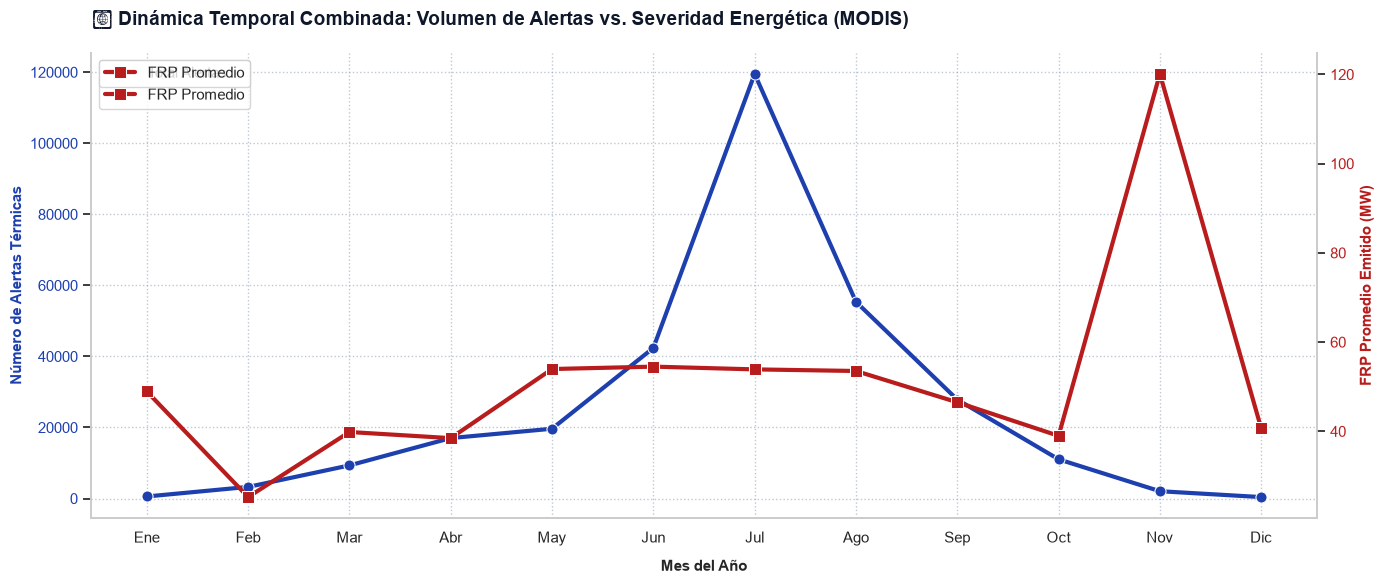

In [ ]:
# Tendencia temporal: análisis avanzado por mes y trimestre
# Configurar estética nativa de Jupyter / Colab
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def generar_analisis_temporal_avanzado(dataframe):
    # Clonamos para no alterar el dataframe original
    df_temp = dataframe.copy()
    
    # Parsing estricto garantizado
    df_temp['acq_date'] = pd.to_datetime(df_temp['acq_date'], errors='coerce')
    
    # Crear características temporales legibles
    df_temp['mes_num'] = df_temp['acq_date'].dt.month
    
    # Diccionario para forzar los nombres de los meses en español (evita problemas de locale en Colab)
    meses_es = {
        1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
    }
    df_temp['mes_nombre'] = df_temp['mes_num'].map(meses_es)
    df_temp['trimestre'] = 'Q' + df_temp['acq_date'].dt.quarter.astype(str)
    
    # Agrupación temporal corregida
    tabla_temporal = df_temp.groupby(['mes_num', 'mes_nombre', 'trimestre']).agg(
        total_detecciones=('frp', 'count'),
        frp_promedio=('frp', 'mean'),
        frp_maximo=('frp', 'max'),
        confianza_media=('confidence', 'mean')
    ).reset_index().sort_values('mes_num')
    
    print("\n📊 --- Comportamiento Agregado por Criterio Temporal ---")
    print(tabla_temporal.to_string(index=False))
    
    # Construcción del Gráfico de Líneas Multieje Profesional
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Primer Eje (Izquierdo): Volumetría de alertas
    color_alertas = '#1e40af' # Azul oscuro técnico
    ax1.set_xlabel('Mes del Año', fontsize=11, fontweight='semibold', labelpad=10)
    ax1.set_ylabel('Número de Alertas Térmicas', color=color_alertas, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='total_detecciones', 
        marker='o', markersize=8, color=color_alertas, ax=ax1, linewidth=3, label='Total Alertas'
    )
    ax1.tick_params(axis='y', labelcolor=color_alertas)
    ax1.grid(True, linestyle=':', alpha=0.6, color='#94a3b8') # Rejilla sutil de fondo
    
    # Segundo Eje (Derecho): Severidad Energética (FRP)
    ax2 = ax1.twinx()
    color_frp = '#b91c1c' # Rojo fuego premium
    ax2.set_ylabel('FRP Promedio Emitido (MW)', color=color_frp, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='frp_promedio', 
        marker='s', markersize=8, color=color_frp, ax=ax2, linewidth=3, label='FRP Promedio'
    )
    ax2.tick_params(axis='y', labelcolor=color_frp)
    ax2.grid(False) # Evitamos que las rejillas se crucen
    
    # Unificar leyendas de ambos ejes en una sola esquina limpia
    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', frameon=True)
    
    # Títulos y limpieza de bordes
    plt.title('📅 Dinámica Temporal Combinada: Volumen de Alertas vs. Severidad Energética (MODIS)', 
              fontsize=14, fontweight='bold', color='#0f172a', pad=20, loc='left')
    
    sns.despine(ax=ax1, top=True, left=False, right=False)
    sns.despine(ax=ax2, top=True, left=False, right=False)
    
    plt.tight_layout()
    return fig, tabla_temporal

# Lanzar proceso usando tu DataFrame df_clean
fig, tabla_resumen = generar_analisis_temporal_avanzado(df_clean)
plt.show()

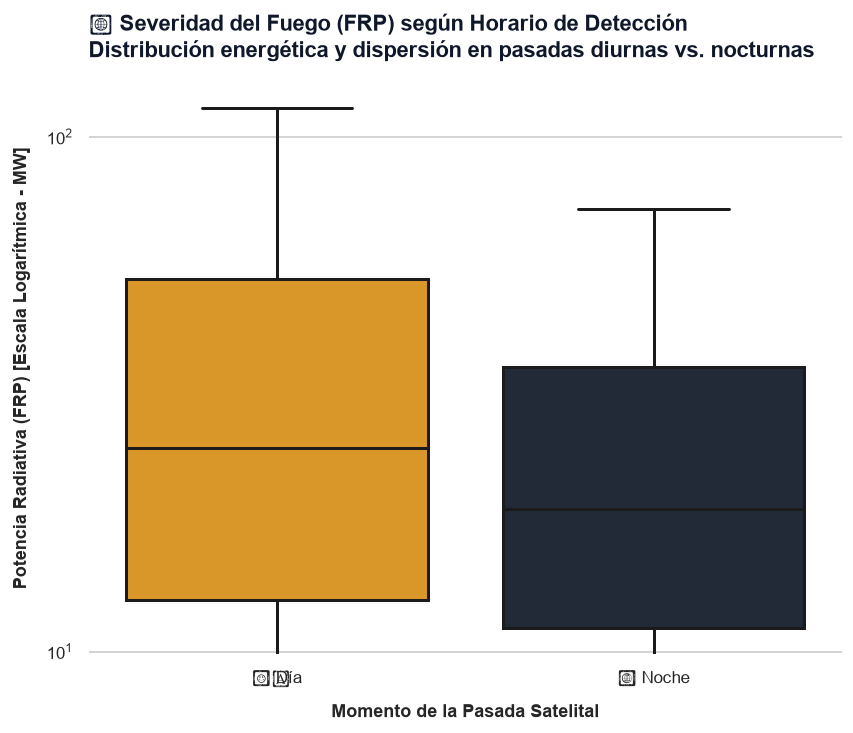

In [ ]:
# Distribución de focos por franja horaria (Día vs Noche)
# Configurar estética de alta definición
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 120  # Nitidez óptima

def plot_fire_severity_day_night(dataframe):
    # Crear copia interna para evitar SettingWithCopyWarning
    df_temp = dataframe.copy()
    
    # Comprobación de seguridad para la columna daynight
    if 'daynight' not in df_temp.columns:
        raise ValueError("El DataFrame no contiene la columna 'daynight'")

    # SOLUCON ANTI-CHOF: Definimos una proporción vertical/cuadrada saludable
    # Un boxplot Día vs Noche
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

    df_temp['daynight_label'] = df_temp['daynight'].map({'D': '☀️ Día', 'N': '🌙 Noche'})
    
    # Gráfico de caja (Boxplot) de Alta Fidelidad
    sns.boxplot(
        ax=ax, 
        data=df_temp, 
        x='daynight_label', 
        y='frp', 
        hue='daynight_label',
        showfliers=False,       # Oculta outliers extremos para que la caja "respire" bien
        palette=['#f59e0b', '#1e293b'], # Ámbar para el día, Pizarra oscuro para la noche
        linewidth=1.8,
        legend=False
    )
    
    # Escala adaptativa inteligente (Logarítmica si los datos están muy dispersos)
    if df_temp['frp'].max() / df_temp['frp'].median() > 15:
        ax.set_yscale('log')
        ax.set_ylabel('Potencia Radiativa (FRP) [Escala Logarítmica - MW]', fontsize=11, fontweight='semibold', labelpad=10)
    else:
        ax.set_ylabel('Potencia Radiativa del Fuego (FRP - MW)', fontsize=11, fontweight='semibold', labelpad=10)

    # Refinamiento de etiquetas y títulos estilo Dashboard Senior
    ax.set_xlabel('Momento de la Pasada Satelital', fontsize=11, fontweight='semibold', labelpad=10)
    ax.tick_params(labelsize=10)
    
    plt.title('🔥 Severidad del Fuego (FRP) según Horario de Detección\n'
              'Distribución energética y dispersión en pasadas diurnas vs. nocturnas', 
              fontsize=13, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.3)
    
    # Limpieza de bordes innecesarios
    sns.despine(left=True, bottom=True)
    
    return fig

# Lanzamiento directo sobre tu df_clean
fig_severity = plot_fire_severity_day_night(df_clean)
plt.show()

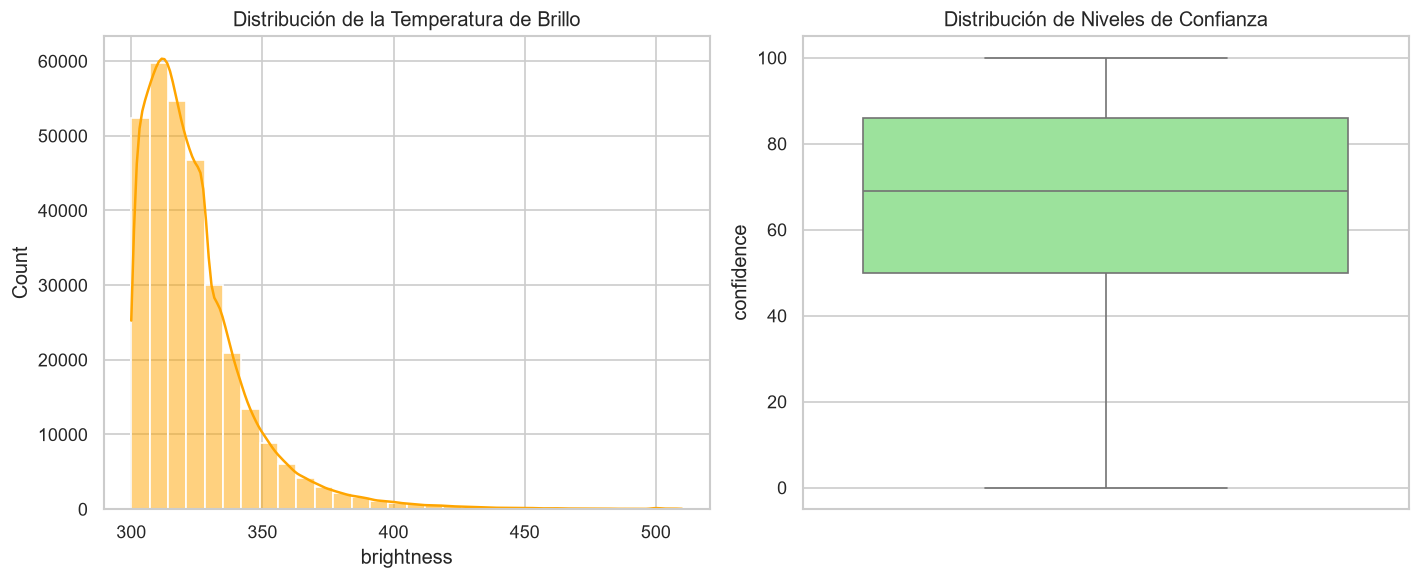

In [ ]:
# Análisis de intensidad (distribución de FRP y brillo)
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Histograma de la potencia radiativa del fuego (FRP) o brillo
plt.subplot(1, 2, 1)
sns.histplot(df['brightness'], bins=30, kde=True, color='orange')
plt.title('Distribución de la Temperatura de Brillo')

# Boxplot de Confianza para ver si hay anomalías o ruido
plt.subplot(1, 2, 2)
sns.boxplot(y=df['confidence'], color='lightgreen')
plt.title('Distribución de Niveles de Confianza')

plt.tight_layout()
plt.show()

## **6. Análisis Geoespacial y mapas de calor**

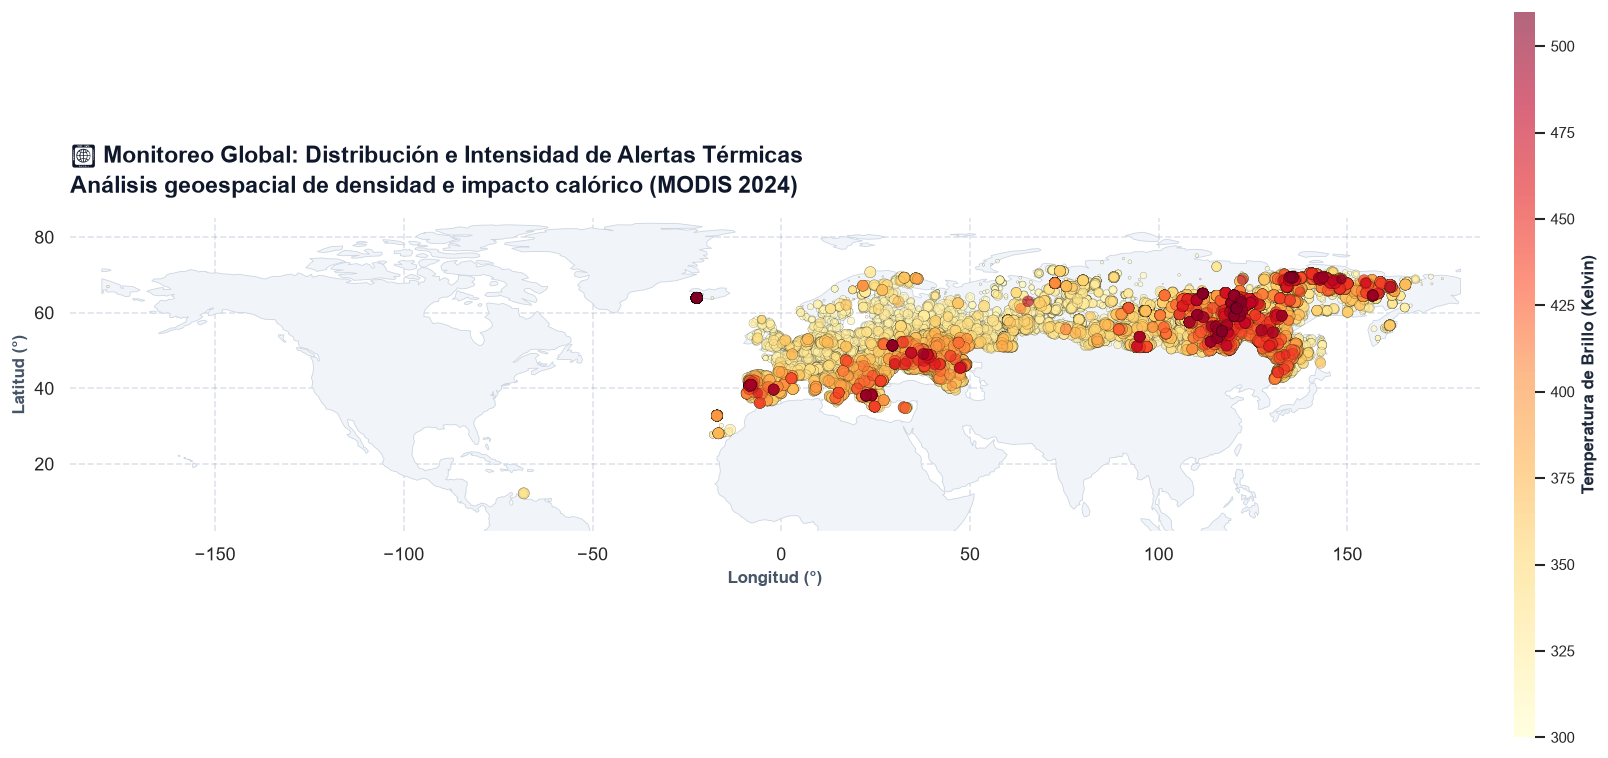

In [ ]:
# Visualización de densidad de puntos
# Configurar entorno estético nativo de Jupyter
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 120  

def render_pro_map_with_background(dataframe):
    fig, ax = plt.subplots(figsize=(15, 9))
    
    url_world = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(url_world)
    world.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.5)
    
    # Pipeline de datos: Evitar Overplotting (Fuegos intensos al frente)
    df_sorted = dataframe.sort_values(by='brightness', ascending=True)
    
    # Escalado semántico para el tamaño basado en confianza
    sizes = (df_sorted['confidence'] / 100) ** 2 * 45

    # Renderizado de las Alertas Térmicas sobre el mapa
    scatter = ax.scatter(
        x=df_sorted['longitude'],
        y=df_sorted['latitude'],
        c=df_sorted['brightness'],
        s=sizes,
        cmap='YlOrRd',       
        alpha=0.6,           
        edgecolors='black',  
        linewidths=0.15,
        zorder=3 # Garantiza que los puntos queden por encima del mapa
    )

    # Estilizado de la barra de color
    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, aspect=35, shrink=0.7)
    cbar.set_label('Temperatura de Brillo (Kelvin)', fontsize=10, fontweight='semibold', color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False) 

    # Límites geográficos 
    ax.set_xlim(dataframe['longitude'].min() - 10, dataframe['longitude'].max() + 10)
    ax.set_ylim(dataframe['latitude'].min() - 10, dataframe['latitude'].max() + 10)

    # Arquitectura de Diseño
    ax.set_title('🔥 Monitoreo Global: Distribución e Intensidad de Alertas Térmicas\n'
                 'Análisis geoespacial de densidad e impacto calórico (MODIS 2024)', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a',
                 linespacing=1.4)
    
    ax.set_xlabel('Longitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    ax.set_ylabel('Latitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    
    sns.despine(left=True, bottom=True)
    ax.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')
    
    plt.tight_layout()
    return fig

# Lanzar el gráfico definitivo
fig = render_pro_map_with_background(df)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


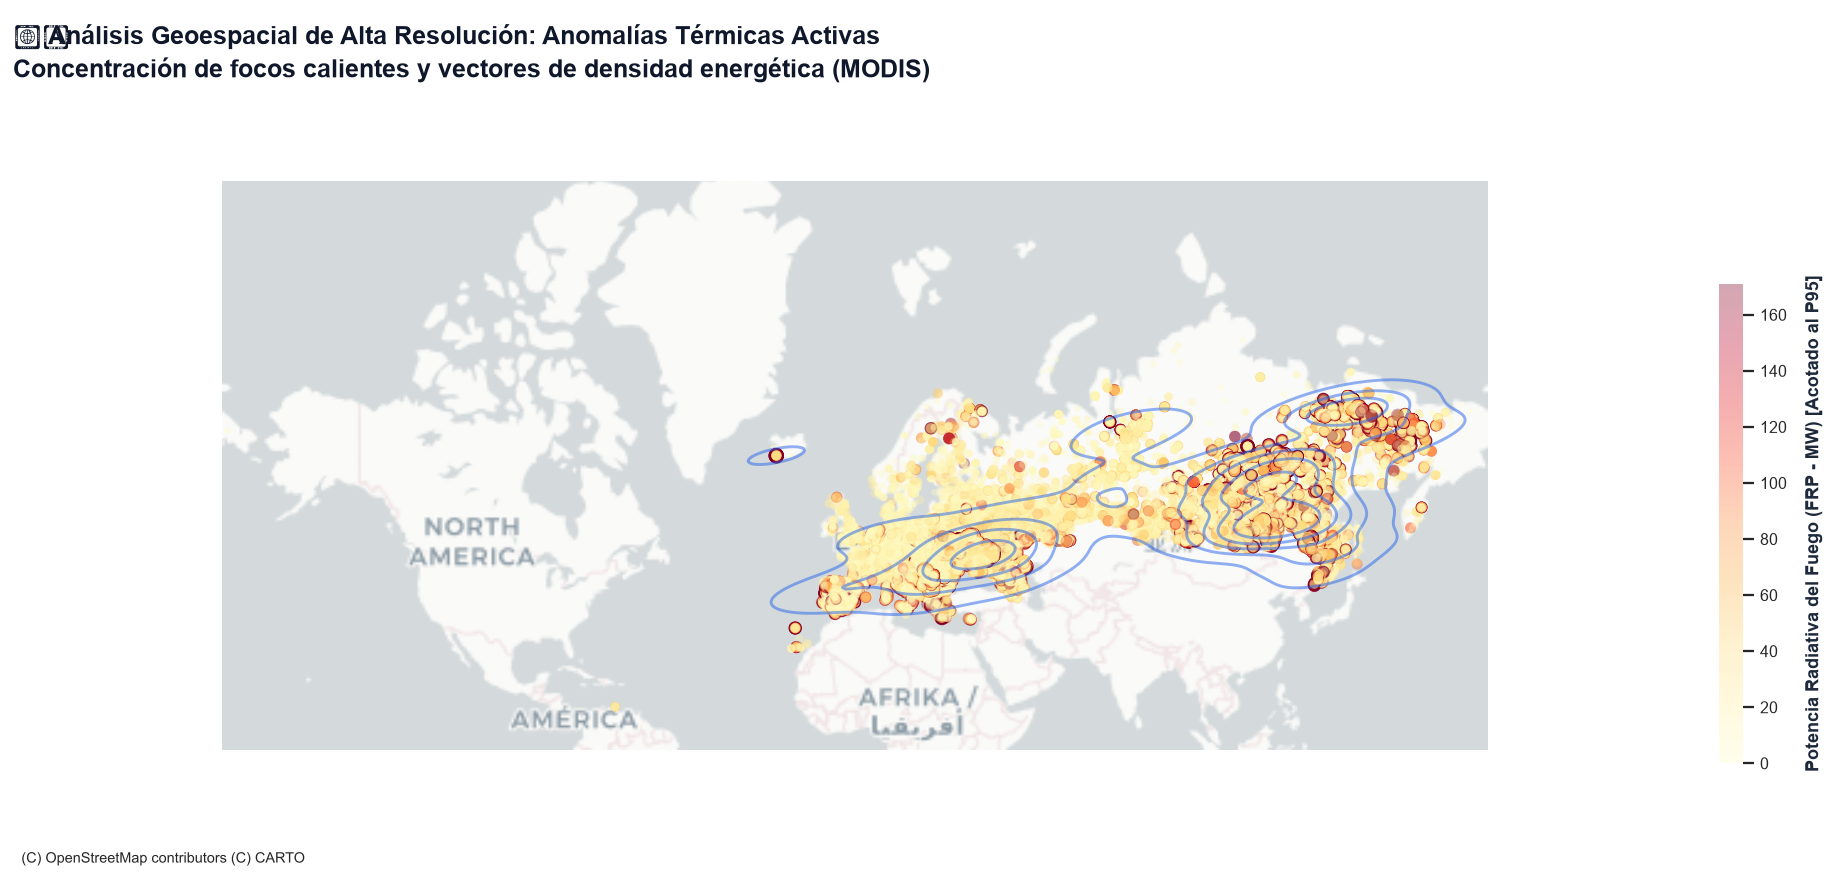

In [ ]:
# Distribución geoespacial avanzada con densidad de focos y curvas KDE
# Configurar entorno estético
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 130

def render_mapa_perfecto(dataframe):
    # Convertir el DataFrame a un GeoDataFrame (fijando WGS84 - EPSG:4326)
    gdf = gpd.GeoDataFrame(
        dataframe, 
        geometry=gpd.points_from_xy(dataframe['longitude'], dataframe['latitude']),
        crs="EPSG:4326"
    )
    
    # Transformar automáticamente a Web Mercator (EPSG:3857), que es el que usa CartoDB
    gdf = gdf.to_crs(epsg=3857)
    
    # Extraer las coordenadas ya proyectadas de forma segura
    x = gdf.geometry.x
    y = gdf.geometry.y

    # Calcular dimensiones para el aspecto automático
    ancho_datos = x.max() - x.min() if len(x) > 1 else 150000
    alto_datos = y.max() - y.min() if len(y) > 1 else 150000
    aspect_ratio_datos = alto_datos / ancho_datos

    ancho_fig = 14
    alto_fig = max(6, min(ancho_fig * aspect_ratio_datos, 11))

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig), layout="constrained")
    ax.set_aspect('equal', adjustable='datalim')

    v_max = gdf['frp'].quantile(0.95)

    # Graficar focos de calor
    scatter = ax.scatter(
        x=x, y=y,
        c=gdf['frp'], cmap='YlOrRd',
        s=np.log1p(gdf['frp']) * 8, 
        alpha=0.35, 
        edgecolors='none', 
        norm=plt.Normalize(vmin=0, vmax=v_max),
        zorder=2
    )

    # Curvas KDE con muestreo dinámico
    if len(gdf) > 5000:
        gdf_kde = gdf.sample(5000, random_state=42)
    else:
        gdf_kde = gdf

    sns.kdeplot(
        x=gdf_kde.geometry.x, y=gdf_kde.geometry.y, ax=ax,
        levels=6, color='#2563eb', linewidths=1.6, alpha=0.5,
        zorder=3
    )

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=1)

    # Padding adaptativo
    pad_x = ancho_datos * 0.08
    pad_y = alto_datos * 0.08
    ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
    ax.set_ylim(y.min() - pad_y, y.max() + pad_y)

    # Limpieza y Barra de color
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.7)
    cbar.set_label('Potencia Radiativa del Fuego (FRP - MW) [Acotado al P95]', 
                   fontsize=10, fontweight='semibold', labelpad=10, color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    plt.title('🗺️ Análisis Geoespacial de Alta Resolución: Anomalías Térmicas Activas\n'
              'Concentración de focos calientes y vectores de densidad energética (MODIS)', 
              fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.4)
    
    sns.despine(left=True, bottom=True)
    return fig

# Ejecutar
fig_mapa_premium = render_mapa_perfecto(df_clean)
plt.show()



## **7. Preparación de variables para algoritmos de clustering**

In [8]:
# --- Core libraries ---
import warnings                       # To handle warning messages
import glob                           # For working with file paths/patterns

# --- Data manipulation ---
import pandas as pd                   # Data analysis and manipulation
import numpy as np                    # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt       # Plotting
import matplotlib.colors as mcolors   # Advanced color handling for matplotlib
import seaborn as sns                 # Statistical plotting (built on matplotlib)
import folium                         # Interactive maps
import branca.colormap as cm          # Colormaps for Folium visualizations

# --- Machine learning / forecasting ---
from prophet import Prophet           # Time series forecasting
from sklearn.metrics import mean_absolute_error  # Model evaluation metric

# --- Pandas extensions ---
from pandas.api.types import CategoricalDtype    # Handling categorical dtypes

# --- Global settings ---
warnings.filterwarnings("ignore")     # Suppress warnings
plt.style.use('ggplot')               # Set plot style
plt.style.use('fivethirtyeight')      # Override with another style

# --- Custom utility functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error (MAPE) given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
import os
import pandas as pd
import urllib.request

# 1. Definición de rutas y URLs
# URL para tiempo real (últimas 24h)
url_tiempo_real = "https://firms.modaps.eosdis.nasa.gov/data/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Europe_24h.csv"

# URLs de los históricos oficiales de FIRMS para España/Europa (años 2021 a 2025)
urls_historicos = {
    2021: "https://firms.modaps.eosdis.nasa.gov/data/country/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Spain_2021.csv",
    2022: "https://firms.modaps.eosdis.nasa.gov/data/country/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Spain_2022.csv",
    2023: "https://firms.modaps.eosdis.nasa.gov/data/country/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Spain_2023.csv",
    2024: "https://firms.modaps.eosdis.nasa.gov/data/country/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Spain_2024.csv",
    2025: "https://firms.modaps.eosdis.nasa.gov/data/country/active_fire/suomi-npp-viirs-c2/csv/SUOMI_VIIRS_C2_Spain_2025.csv"
}

folder_path = os.path.join('data', 'historicos_españa', 'años')
output_path = os.path.join('data', 'historicos_españa', 'modis_historicos_españa.csv')

# Crear los directorios si no existen
os.makedirs(folder_path, exist_ok=True)

# 2. Descarga y filtrado de datos en TIEMPO REAL (Últimas 24 horas)
print("1. Descargando datos en tiempo real (últimas 24h) de Europa...")
try:
    df_europa_rt = pd.read_csv(url_tiempo_real)
    
    # Límites geográficos de España para filtrar el dataset de Europa en tiempo real:
    # Península y Baleares: Lat [35.0, 44.0], Lon [-10.0, 4.5]
    # Canarias: Lat [27.0, 30.0], Lon [-19.0, -13.0]
    df_spain_main = df_europa_rt[
        (df_europa_rt['latitude'].between(35.0, 44.0)) & 
        (df_europa_rt['longitude'].between(-10.0, 4.5))
    ]
    df_spain_canary = df_europa_rt[
        (df_europa_rt['latitude'].between(27.0, 30.0)) & 
        (df_europa_rt['longitude'].between(-19.0, -13.0))
    ]
    
    df_tiempo_real_spain = pd.concat([df_spain_main, df_spain_canary], ignore_index=True)
    
    # Guardamos el archivo de tiempo real
    rt_file_path = os.path.join(folder_path, "SUOMI_VIIRS_C2_Spain_24h.csv")
    df_tiempo_real_spain.to_csv(rt_file_path, index=False)
    print(f"-> Tiempo real de España guardado en: {rt_file_path}")
    
except Exception as e:
    print(f"-> Error descargando tiempo real ({e}). Se usarán los datos locales existentes.")

# 3. Descarga automática de los históricos oficiales (2021 - 2025)
print("\n2. Comprobando y descargando históricos (2021-2025)...")
for año, url in urls_historicos.items():
    archivo_local = os.path.join(folder_path, f"SUOMI_VIIRS_C2_Spain_{año}.csv")
    if not os.path.exists(archivo_local):
        print(f"Descargando histórico del año {año}...")
        try:
            # FIRMS ofrece directamente archivos filtrados por país
            urllib.request.urlretrieve(url, archivo_local)
            print(f"-> Guardado {archivo_local}")
        except Exception as e:
            print(f"-> No se pudo descargar el año {año} de FIRMS ({e}).")
    else:
        print(f"-> El archivo del año {año} ya existe de forma local.")

# 4. Consolidación de todos los archivos de la carpeta
print("\n3. Consolidando todos los archivos...")
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

if len(csv_files) > 0:
    # Combinar todos los CSVs (históricos + tiempo real)
    dfs_lista = []
    for file in csv_files:
        df_temp = pd.read_csv(file)
        dfs_lista.append(df_temp)
        
    df_españa = pd.concat(dfs_lista, ignore_index=True)

    # Eliminar posibles registros duplicados entre históricos y tiempo real
    subset_cols = ['latitude', 'longitude', 'acq_date', 'acq_time']
    df_españa.drop_duplicates(subset=[col for col in subset_cols if col in df_españa.columns], inplace=True)

    # 5. Procesamiento de Fechas, Indexación y Ordenación
    df_españa['acq_date'] = pd.to_datetime(df_españa['acq_date'])
    df_españa.set_index('acq_date', inplace=True)
    df_españa.sort_index(inplace=True)

    # 6. Guardar el archivo unificado final
    df_españa.to_csv(output_path)
    print(f"\n¡Éxito! Archivo final generado: '{output_path}'")
    print(f"Total registros consolidados (2021-2025 + TR): {len(df_españa)}")
    print("\nPrimeras filas del resultado:")
    print(df_españa.head())
else:
    print("Error: No se encontraron archivos para consolidar.")

1. Descargando datos en tiempo real (últimas 24h) de Europa...
-> Tiempo real de España guardado en: data\historicos_españa\años\SUOMI_VIIRS_C2_Spain_24h.csv

2. Comprobando y descargando históricos (2021-2025)...
Descargando histórico del año 2021...
-> No se pudo descargar el año 2021 de FIRMS (HTTP Error 404: Not Found).
Descargando histórico del año 2022...
-> No se pudo descargar el año 2022 de FIRMS (HTTP Error 404: Not Found).
Descargando histórico del año 2023...
-> No se pudo descargar el año 2023 de FIRMS (HTTP Error 404: Not Found).
Descargando histórico del año 2024...
-> No se pudo descargar el año 2024 de FIRMS (HTTP Error 404: Not Found).
Descargando histórico del año 2025...
-> No se pudo descargar el año 2025 de FIRMS (HTTP Error 404: Not Found).

3. Consolidando todos los archivos...

¡Éxito! Archivo final generado: 'data\historicos_españa\modis_historicos_españa.csv'
Total registros consolidados (2021-2025 + TR): 0

Primeras filas del resultado:
Empty DataFrame
Colum

: 

In [ ]:
columns_to_drop = ['acq_time', 'satellite', 'instrument', 'version', 'daynight']
df_españa.drop(columns=columns_to_drop, inplace=True)
df_españa.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2017-01-01,43.5326,-5.7263,316.4,1.0,1.0,93,275.1,20.6,0
2017-01-01,42.3891,-6.5918,300.4,1.0,1.0,27,269.8,9.6,0
2017-01-01,43.0390,-6.5395,317.5,1.0,1.0,95,272.6,21.5,0
2017-01-01,42.8756,-5.0808,301.0,1.3,1.1,43,280.8,10.7,0
2017-01-01,42.3787,-6.5832,308.9,1.1,1.1,43,283.5,11.4,0


In [ ]:
min_latitude, max_latitude = 35.75990867279711, 44.396061584304846
min_longitude, max_longitude = -10.462632147777299, 3.3279086334759427

df_filtered = df_españa[(df_españa['latitude'] >= min_latitude) & (df_españa['latitude'] <= max_latitude) & (df_españa['longitude'] >= min_longitude) & (df_españa['longitude'] <= max_longitude)]

print(f"Número de filas tras el filtrado: {len(df_españa)}")

Número de filas tras el filtrado: 28328


In [ ]:
def plot_frp_by_timeframe(df_españa, year, month=None):
    """
    Generates a line plot of Fire Radiative Power (FRP) for a specific year and optional month,
    or a bar graph of monthly median FRP for a specific year.

    Args:
        df_españa (pd.DataFrame): The input DataFrame with a datetime index.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). If None, a bar graph
                               of monthly median FRP for the year is generated.
    """
    if month is not None:
        df_filtered = df_españa[(df_españa.index.year == year) & (df_españa.index.month == month)].copy()
        timeframe_str = f"Fire Radiative Power (FRP) for {month}/{year}"
        plot_type = 'line'
    else:
        df_filtered = df_españa[df_españa.index.year == year].copy()
        timeframe_str = f"Monthly Median Fire Radiative Power (FRP) for {year}"
        plot_type = 'bar'

    if df_filtered.empty:
        print(f"No data found for {timeframe_str.replace('Monthly Median ', '')}")
        return

    plt.figure(figsize=(12, 6))

    if plot_type == 'line':
        plt.plot(df_filtered.index, df_filtered['frp'])
        plt.xlabel('Date')
        plt.ylabel('FRP')
    elif plot_type == 'bar':
        # Group by month and calculate the mean FRP
        monthly_frp = df_filtered.resample('ME')['frp'].mean()
        monthly_frp.index = monthly_frp.index.strftime('%Y-%m') # Format for x-axis
        monthly_frp.plot(kind='bar')
        plt.xlabel('Month')
        plt.ylabel('Median FRP')
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    plt.title(timeframe_str)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()

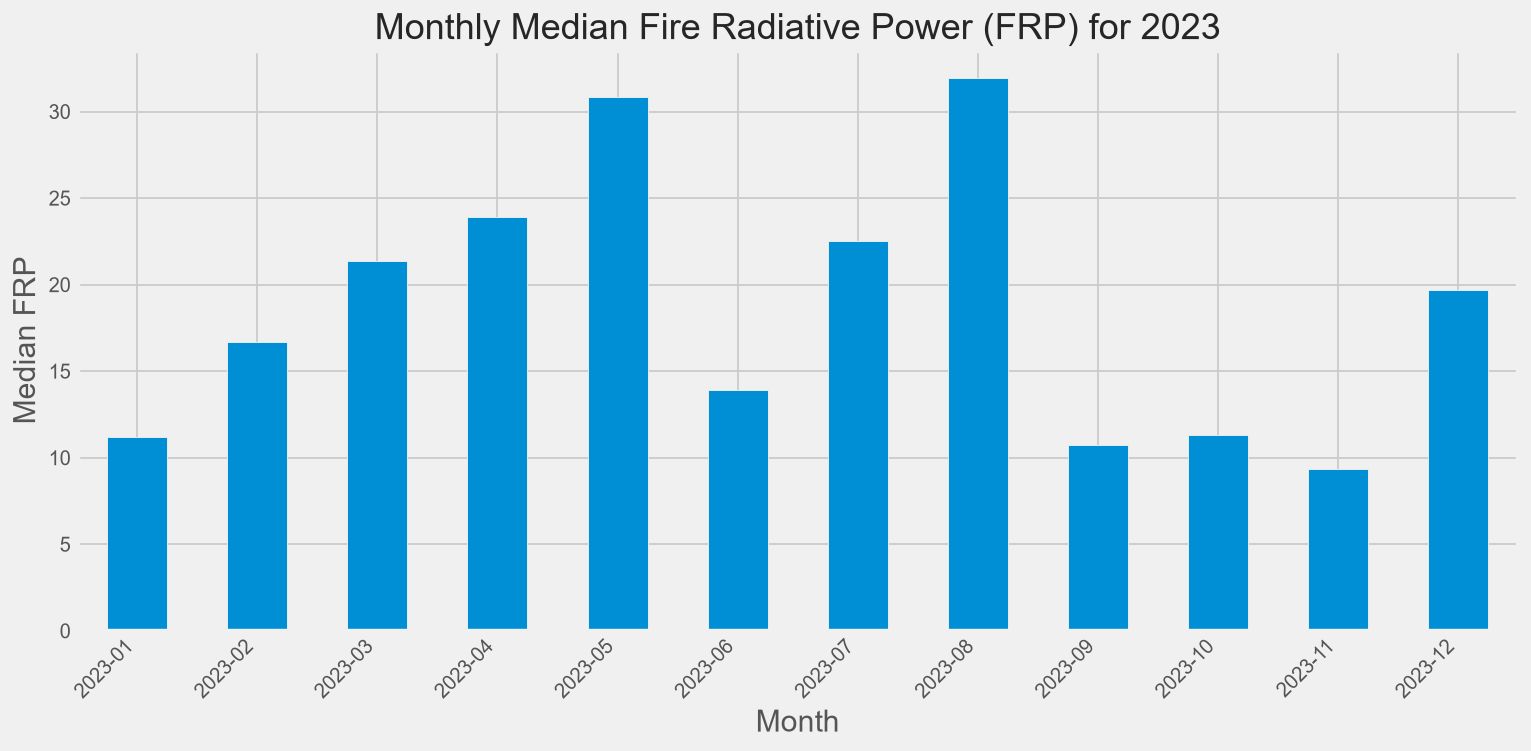

In [ ]:
# TODO: Change year
year = 2023

 # Bar graph for the year
plot_frp_by_timeframe(df_españa, year)

In [ ]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import branca.colormap as cm

def plot_intense_fires_folium(df, year, month=None):
    """
    Generates an interactive map showing the locations of intense fires (FRP >= 100)
    for a specific year and optional month using Folium, centered in Spain.

    Args:
        df (pd.DataFrame): The input DataFrame with a datetime index and
                           'latitude', 'longitude', and 'frp' columns.
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    if month is not None:
        df_filtered = df[(df.index.year == year) & (df.index.month == month)].copy()
        timeframe_str = f"Intense Fires for {month}/{year}"
    else:
        df_filtered = df[df.index.year == year].copy()
        timeframe_str = f"Intense Fires for {year}"

    # Filter for intense fires (FRP >= 100)
    intense_fires_df = df_filtered[df_filtered['frp'] >= 100].copy()

    if intense_fires_df.empty:
        print(f"No intense fires found for {timeframe_str} in Spain")
        return

    # --- CAMBIO AQUÍ: Coordenadas del centro de España y zoom adecuado ---
    m = folium.Map(location=[40.4167, -3.7037], zoom_start=6)

    # Add markers for intense fire locations
    max_frp = intense_fires_df['frp'].max()
    min_frp = intense_fires_df['frp'].min()

    # --- CAMBIO AQUÍ: Corrección para versiones modernas de Matplotlib ---
    cmap = plt.colormaps['YlOrRd'] 
    norm = mcolors.Normalize(vmin=min_frp, vmax=max_frp)

    for index, row in intense_fires_df.iterrows():
        # Scale FRP to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['frp'] - min_frp) / (max_frp - min_frp) * 13 if max_frp > min_frp else 5
        # Scale FRP to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['frp'] - min_frp) / (max_frp - min_frp) * 0.5 if max_frp > min_frp else 0.7

        # Get color from colormap based on FRP value
        color = mcolors.to_hex(cmap(norm(row['frp'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP: {row['frp']:.2f}"
        ).add_to(m)

    # Add a legend adaptativa basada en los datos reales
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[min_frp, (min_frp + max_frp) / 2, max_frp],
        vmin=min_frp,
        vmax=max_frp
    )

    # Add the colormap as a legend to the map
    colormap.caption = f'Fire Radiative Power (FRP) - range: {min_frp:.0f} to {max_frp:.0f}'
    colormap.add_to(m)

    # Display the map
    display(m)

In [ ]:
# TODO: Change year and month
year = 2024
month = 7

plot_intense_fires_folium(df_españa, year, month)

In [ ]:
m = folium.Map(location=[(min_latitude + max_latitude) / 2, (min_longitude + max_longitude) / 2], zoom_start=6)

folium.Rectangle(
    bounds=[(min_latitude, min_longitude), (max_latitude, max_longitude)],
    color='#ff7800',
    weight=2,
    fill=True,
    fill_color='#ffff00',
    fill_opacity=0.2
).add_to(m)

display(m)


In [ ]:
# Aggregate by daily, drop latitude and longitude, and median other features
df_españa = df_filtered.resample('D').median()

# Drop NaN values
df_españa.dropna(inplace=True)

# Display the dataset
df_españa.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2017-01-01,42.38220,-6.5900,308.90,1.10,1.10,55.0,280.80,12.30,0.0
2017-01-02,43.33660,-4.7388,307.85,1.15,1.05,63.0,271.75,16.35,0.0
2017-01-03,41.88430,-3.7680,310.00,1.00,1.00,69.0,271.00,18.90,0.0
2017-01-04,43.07355,-1.6749,304.20,1.20,1.10,58.0,279.90,15.85,0.0
2017-01-05,42.38070,-3.7316,306.50,1.10,1.00,63.0,284.70,8.30,0.0


Text(0, 0.5, 'FRP')

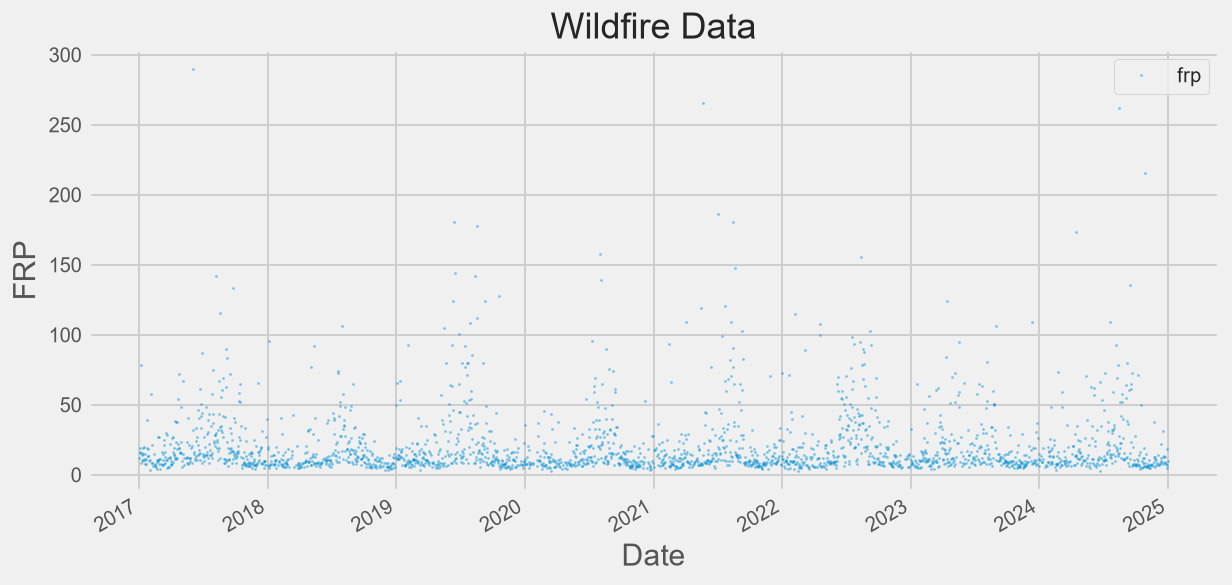

In [ ]:
# Get the default seaborn color palette (list of colors to use in plots)
color_pal = sns.color_palette()

# Plot the 'frp' column from the DataFrame
df_españa.plot(
    style='.',                # Plot style: '.' means scatter-style points
    y='frp',                  # Column to plot on the y-axis
    figsize=(10, 5),          # Set the figure size (width=10, height=5)
    ms=1,                     # Marker size (small points since the dataset may be large)
    color=color_pal[0],       # Use the first color from the seaborn palette
    title='Wildfire Data',    # Title for the plot
    alpha=0.5                 # Set transparency (helps reduce overplotting)
)

# Label the x-axis and y-axis
plt.xlabel('Date')            # X-axis label: dates (time series)
plt.ylabel('FRP')             # Y-axis label: Fire Radiative Power

In [ ]:
def create_features(df_españa):
    """
    Crea características de series temporales a partir del índice datetime 
    y las concatena al dataframe df_españa original.
    """
    df_españa = df_españa.copy()
    df_españa['date'] = df_españa.index
    df_españa['month'] = df_españa['date'].dt.month
    df_españa['weekofyear'] = df_españa['date'].dt.isocalendar().week.astype(int)
    df_españa['date_offset'] = (df_españa.date.dt.month * 100 + df_españa.date.dt.day - 320) % 1300

    # Clasificación de estaciones en español
    df_españa['season'] = pd.cut(df_españa['date_offset'], [0, 300, 602, 900, 1300],
                                 labels=['Primavera', 'Verano', 'Otoño', 'Invierno'],
                                 include_lowest=True)
    
    df_españa = df_españa.drop(columns=['date', 'date_offset']) # Elimina columnas temporales

    return df_españa

# Aplicación y separación de características (X) y variable objetivo (y)
df_features = create_features(df_españa)
X = df_features.drop(columns=['frp'])
y = df_features['frp']

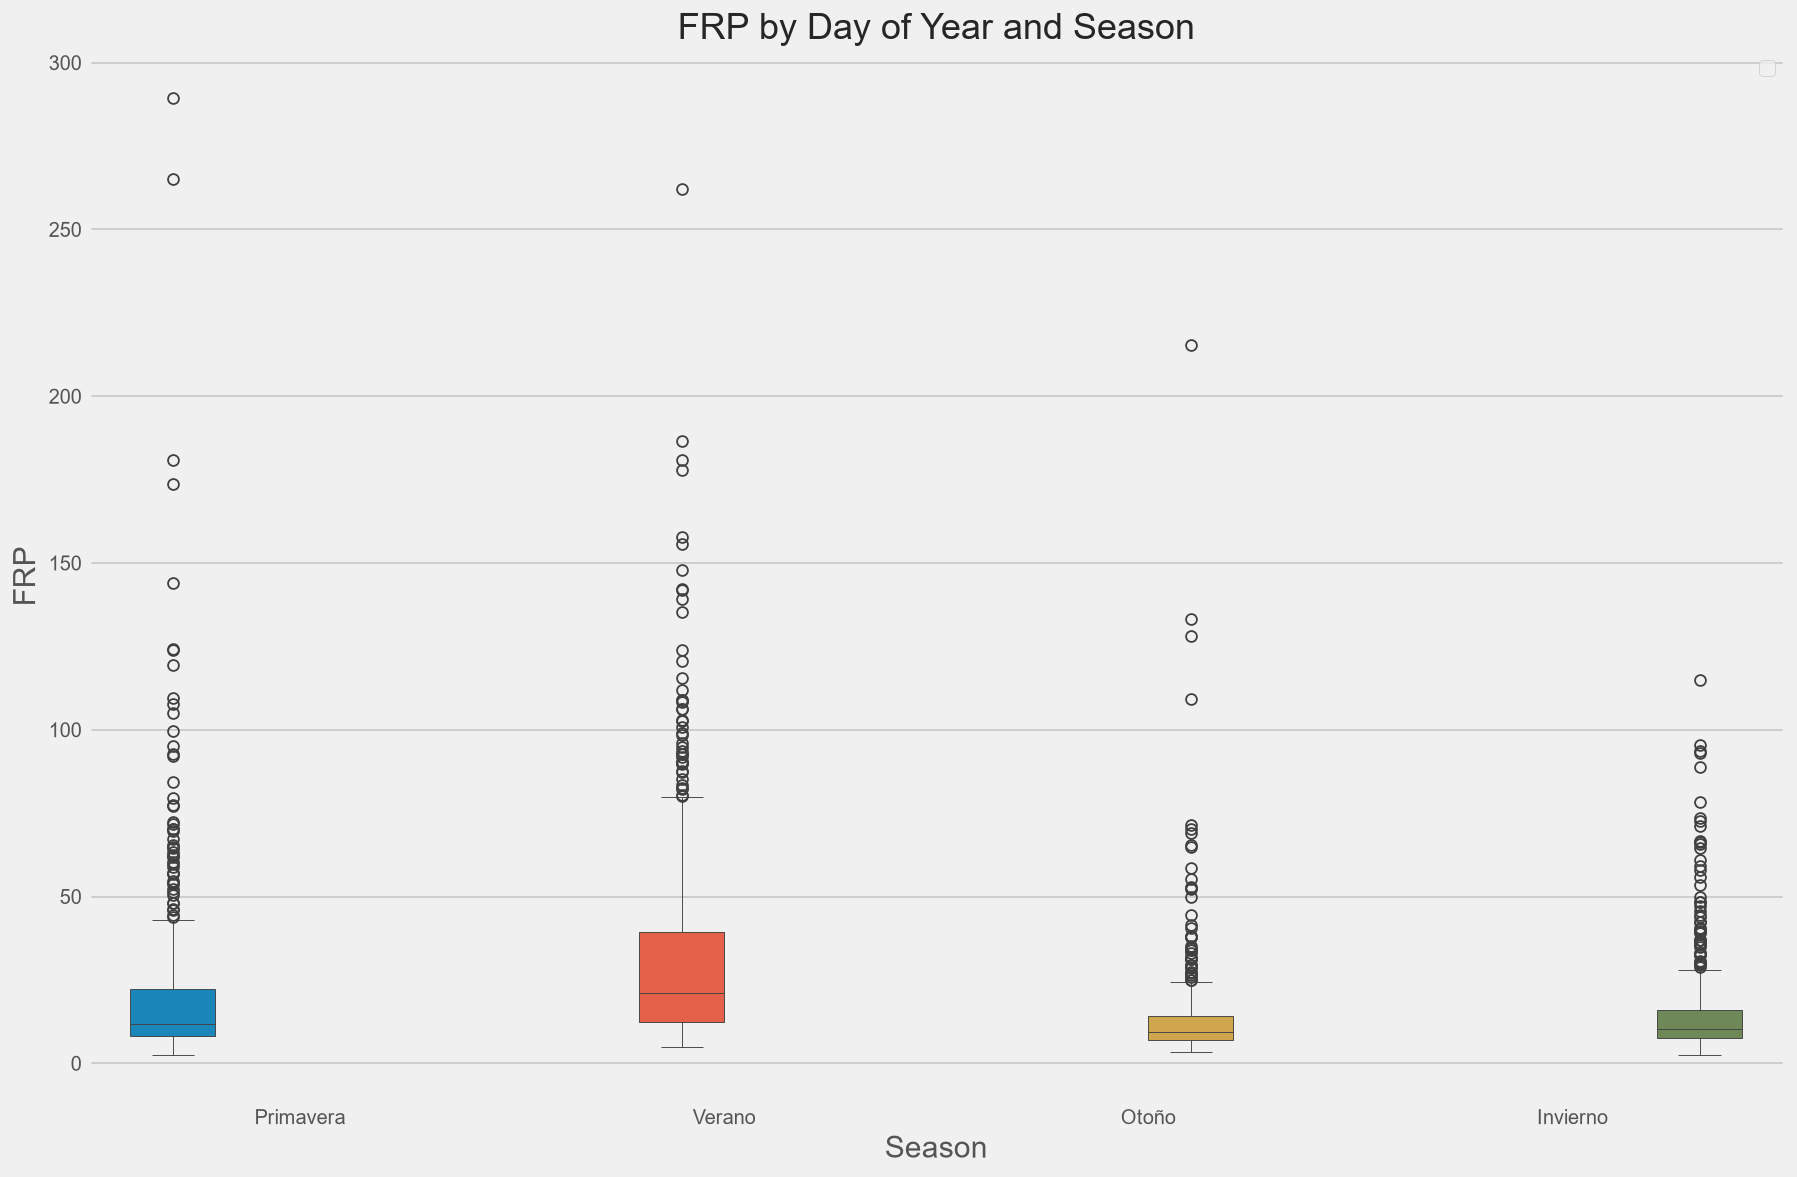

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10)) # Increased figure size
sns.boxplot(data=df_features.dropna(),
            x='season',
            y='frp',
            hue='season',
            ax=ax,
            linewidth=0.5) # Slightly reduced linewidth
ax.set_title('FRP by Day of Year and Season')
ax.set_xlabel('Season')
ax.set_ylabel('FRP')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

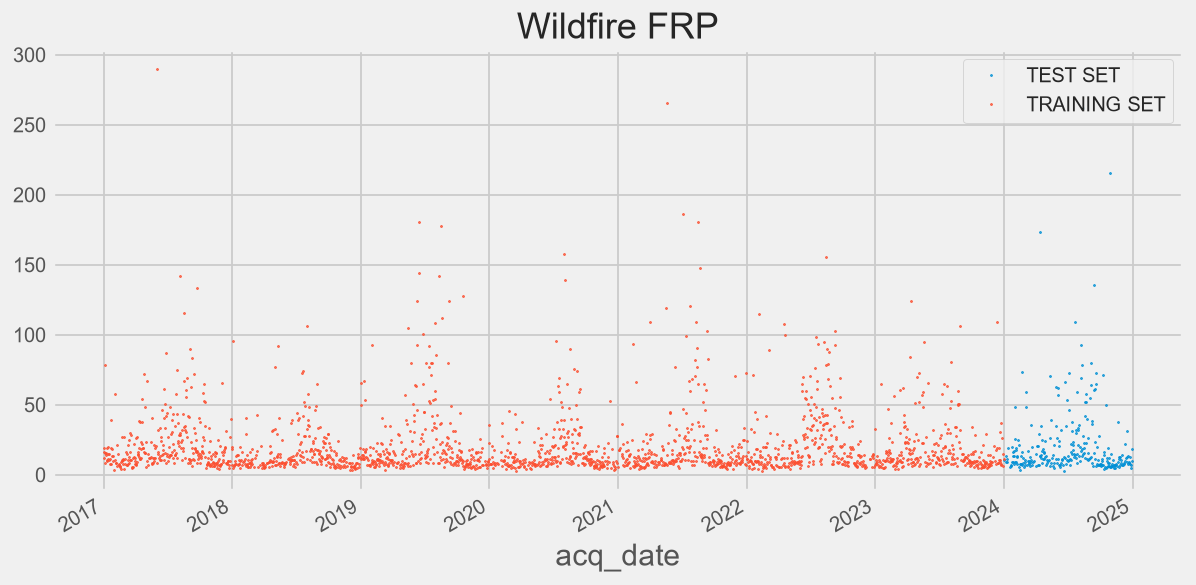

In [ ]:
# TODO: Change date
split_date = '1-Jan-2024'
df_train = df_features.loc[df_features.index <= split_date].copy()
df_test = df_features.loc[df_features.index > split_date].copy()

# Plot train and test so you can see where we have split
pd.concat([df_test.groupby(df_test.index)['frp'].mean().rename('TEST SET'),
           df_train.groupby(df_train.index)['frp'].mean().rename('TRAINING SET')],
          axis=1) \
    .plot(figsize=(10, 5), title='Wildfire FRP', style='.', ms=1)
plt.show()

In [ ]:
# Format data for prophet model using ds and y
df_train_prophet = df_train.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

In [ ]:
%%time
# Initialize and train the Prophet model
# The Prophet model is a time series forecasting model developed by Facebook
model = Prophet()
# Fit the model to the training data
# This step can take some time as the model learns the patterns in the data
model.fit(df_train_prophet)

13:46:31 - cmdstanpy - INFO - Chain [1] start processing
13:46:31 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 297 ms
Wall time: 829 ms


In [ ]:
# Predict on test set with model
df_test_prophet = df_test.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

# Use the trained Prophet model to make predictions on the test data
df_test_fcst = model.predict(df_test_prophet)

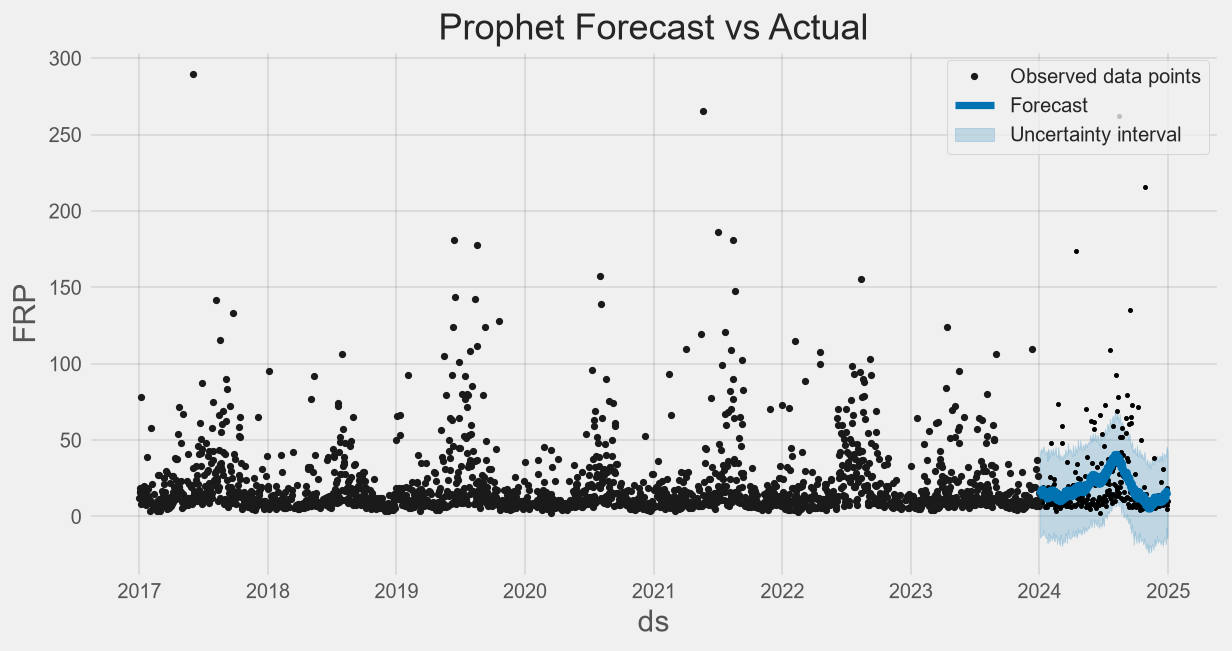

In [ ]:
# Create a figure and axis for plotting, setting the figure size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the Prophet forecast results on the specified axis
fig = model.plot(df_test_fcst, ax=ax)

# Plot the actual values from the test set as scatter points
ax.scatter(df_test_prophet['ds'], df_test_prophet['y'], color='black', s=5)

# Set the plot title
ax.set_title('Prophet Forecast vs Actual')
yaxis = ax.get_yaxis()
yaxis.set_label_text('FRP')

# Add a legend to differentiate between forecast and actual values
ax.legend()

# Display the plot
plt.show()

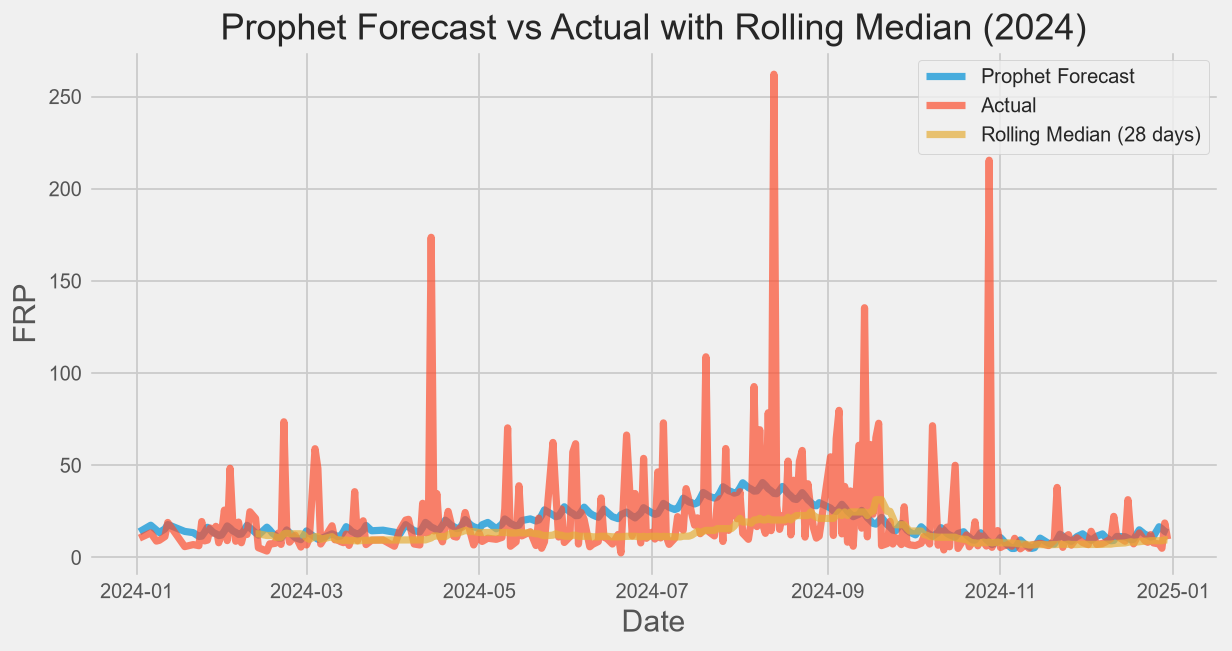

In [ ]:
# Make a graph to compare prediction to actual values with rolling median for the test set
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label='Prophet Forecast', alpha=0.7)
ax.plot(df_test_prophet['ds'], df_test_prophet['y'], label='Actual', alpha=0.7)

# TODO: You can adjust the window size
rolling_window = 28

# Calculate and plot rolling median
df_test_prophet['rolling_avg'] = df_test_prophet['y'].rolling(window=rolling_window).median()
ax.plot(df_test_prophet['ds'], df_test_prophet['rolling_avg'], label=f'Rolling Median ({rolling_window} days)', alpha=0.7)

ax.set_title('Prophet Forecast vs Actual with Rolling Median (2024)')
ax.set_xlabel('Date')
ax.set_ylabel('FRP')
ax.legend()
plt.show()

In [ ]:
# Calculate MAE
mae = mean_absolute_error(df_test['frp'], df_test_fcst['yhat'])
print('MAE:', mae)

MAE: 13.848139448907862


In [ ]:
# Calculate MAPE
mean_absolute_percentage_error(df_test['frp'], df_test_fcst['yhat'])

np.float64(76.84394091978832)

## **11. Mapas de calor colectivos (Folium)**

In [ ]:
# Calcular el centro del mapa basado en los datos
centro_lat = df_clean["latitude"].mean()
centro_lon = df_clean["longitude"].mean()

# Inicializar el mapa base de Folium
mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=8, tiles="OpenStreetMap")

# Preparar los datos para el HeatMap
datos_focos = df_clean[["latitude", "longitude", "brightness"]].values.tolist()

# Crear y añadir la capa de calor al mapa
HeatMap(
    data=datos_focos,
    radius=15,  # Radio de influencia de cada foco en píxeles
    blur=10,    # Grado de desenfoque para suavizar el mapa de calor
    max_zoom=13, # Zoom a partir del cual el punto tiene la máxima intensidad
).add_to(mapa)

# --- MODIFICACIÓN PARA GUARDAR EN LA CARPETA 'data' ---

# Creamos la carpeta 'data' si es que aún no existe para evitar errores
os.makedirs("data", exist_ok=True)

# Guardamos el mapa especificando la ruta de la carpeta
ruta_guardado = os.path.join("data", "mapa_de_focos.html")
mapa.save(ruta_guardado)

print(f"¡Mapa guardado exitosamente en: {ruta_guardado}!")

¡Mapa guardado exitosamente en: data\mapa_de_focos.html!


## **12. Reporte de Análisis Exploratorio de Datos (EDA)**

### **Dataset:** Alertas de Anomalías Térmicas (MODIS 2024)



---

## 1. Resumen Ejecutivo

El conjunto de datos analizado corresponde a las detecciones de anomalías térmicas (focos de calor e incendios) capturadas por el instrumento **MODIS** a bordo de los satélites **Terra** y **Aqua** durante el año **2024**. El conjunto de datos original consolida información de múltiples países con un total de **308,402 registros** y 16 variables iniciales. Tras un proceso riguroso de limpieza, normalización y filtrado de ruido, el dataset quedó optimizado para el análisis.

---

## 2. Calidad de los Datos y Proceso de Limpieza

### **Diagnóstico Inicial**

* **Volumen:** 308,402 filas y 16 columnas.


* **Integridad:** El dataset inicial presentó una **calidad excepcional en términos de completitud, registrando un 0% de valores nulos** en todas sus variables.



### **Transformaciones y Optimizaciones Aplicadas**

1. **Formateo de Tiempo:** Se convirtieron las variables de adquisición (`acq_date` y `acq_time`) y se consolidaron en una única variable de tipo fecha-hora (`acq_datetime`) para permitir análisis de series temporales precisos.


2. **Validación Geográfica:** Se validó que el 100% de las coordenadas estuvieran en los rangos lógicos (Latitud: $-90$ a $90$; Longitud: $-180$ a $180$).


3. **Optimización de Memoria:** Variables con alta repetitividad (`satellite`, `instrument`, `daynight`, `pais`, `type`) fueron transformadas al tipo de dato `category`. Las variables numéricas de temperatura y potencia (`brightness`, `bright_t31`, `frp`) se redondearon a dos decimales, reduciendo el uso de memoria a **49.1 MB**.


4. **Mapeo de Negocio:** La columna categórica `type` fue decodificada desde sus valores numéricos originales a etiquetas legibles:


* **0:** Incendio forestal/vegetación


* **1:** Volcán


* **2:** Industria/Foco estático


* **3:** Otros/Fuera de rango





---

## 3. Análisis Descriptivo e Interpretación de Variables

### **Distribución de Tipos de Focos Térmicos**

Una vez aplicado el mapeo, se observa la siguiente distribución en el dataset:

| Tipo de Foco Térmico | Cantidad de Alertas | Porcentaje |
| --- | --- | --- |
| **Incendio forestal/vegetación** | 279,748 | 90.71% |
| **Industria/Foco estático** | 26,770 | 8.68% |
| **Volcán** | 1,760 | 0.57% |
| **Otros/Fuera de rango** | 124 | 0.04% |

> 📌 **Interpretación:** Más del **90% de las alertas** corresponden a incendios forestales o de vegetación. Esto demuestra que el dataset está masivamente orientado al monitoreo ambiental y de emergencias por fuego, dejando las actividades industriales y volcánicas como eventos secundarios o ruido de fondo controlado.
> 
> 

### **Análisis de la Confianza (Filtro de Ruido)**

La variable `confidence` (0-100%) mide la certidumbre del algoritmo de MODIS sobre si el píxel detectado representa un fuego real.

* **Media original:** 66.09%.


* **Mediana (Percentil 50):** 69.00%.



El EDA propone una estrategia de **limpieza de ruido** eliminando las alertas con confianza baja ($< 50\%$).

* **Registros útiles (Confianza $\ge 50\%$):** 231,964 alertas.


* **Ruido/Falsos positivos eliminados:** 76,438 alertas (24.78% del total).



> 📌 **Interpretación:** Uno de cada cuatro registros originales de MODIS es potencialmente un falso positivo o una medición de baja fiabilidad. Para el entrenamiento de modelos predictivos o análisis de riesgo sectorial, **es mandatorio trabajar con el subset filtrado de 231,964 alertas** para asegurar la precisión de las conclusiones.
> 
> 